In [134]:
#imports
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from matplotlib.collections import PatchCollection
from mpl_toolkits.mplot3d import Axes3D


In [135]:
# Constants
Gravitational_Constant=6.6743*(10)
dt=1.0
total_time=400
time=0.0

In [136]:
def normalize_unit_vector(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
        return v
    return v / norm

In [137]:
#very rough please simplify when you can. Prob cant if we have initial constants
class Body:
    def __init__(self, mass, pos, velo, accel, force):
        self.mass=mass
        self.pos=np.array(pos,dtype=float)
        self.velo=np.array(velo,dtype=float)
        self.accel=np.array(accel,dtype=float)
        self.force=np.array(force,dtype=float)
        
        self.history_pos = [self.pos.copy()]
        self.history_velo = [self.velo.copy()]
        self.history_accel = [self.accel.copy()]
        self.history_force = [self.force.copy()]

    def update_history(self):
        self.history_pos.append(self.pos.copy())
        self.history_velo.append(self.velo.copy())
        self.history_accel.append(self.accel.copy())
        self.history_force.append(self.force.copy())
    
    def get_gravitational_force_2bodies(self, other):
        r_vec = other.pos-self.pos
        dist = np.linalg.norm(r_vec)
        if dist > 10**6:
            zeros=[0,0]
            returnzero=np.array(zeros)
            return (returnzero)
        mag = normalize_unit_vector(r_vec) * ((Gravitational_Constant*self.mass*other.mass)/(dist**2))
        print(mag)
        return (mag)

    

In [138]:
def combining_2_vectors(vector1, vector2): #combines the force of b2 on b1 and b3 on b1 for a total g force acted on b1
    array_one = np.array(vector1)
    array_two = np.array(vector2)
    summed_array = array_one + array_two
    return (summed_array)

In [139]:
bodies = []
# bodies.append(Body( 5*10**8, [10*10**3, -5*10**3], [10**1, 10**1], [0, 0], [0, 0])) #mass and initial( pos velo accel force )
# bodies.append(Body( 3*10**8, [2*10**3, 0], [-2*10**1, 0], [0, 0], [0, 0]))
# bodies.append(Body( 6*10**8, [-8*10**3, 10*10**3], [9*10**1, -5*10**1], [0, 0], [0, 0]))

bodies.append(Body( 3*10**8, [0, 0], [0, 500], [0, 0], [0, 0])) #mass and initial( pos velo accel force )
bodies.append(Body( 3*10**8, [-5*10**4, -7.5*10**4], [500, 0], [0, 0], [0, 0]))
bodies.append(Body( 3*10**8, [5*10**4, -7.5*10**4], [-500, 500], [0, 0], [0, 0]))

center_of_mass = (bodies[0].mass*bodies[0].pos + bodies[1].mass*bodies[1].pos + bodies[2].mass*bodies[2].pos)/(bodies[0].mass*bodies[1].mass*bodies[2].mass)

In [140]:
def CalcTV(bodies):
    T=.5*((bodies[0].mass*(np.linalg.norm(bodies[0].velo)**2)) +(bodies[1].mass*(np.linalg.norm(bodies[1].velo)**2)) +(bodies[2].mass*(np.linalg.norm(bodies[2].velo)**2)))
    mass12=bodies[0].mass*bodies[1].mass
    r12=np.linalg.norm(bodies[0].pos-bodies[1].pos)
    mass13=bodies[0].mass*bodies[2].mass
    r13=np.linalg.norm(bodies[0].pos-bodies[2].pos)
    mass23=bodies[1].mass*bodies[2].mass
    r23=np.linalg.norm(bodies[1].pos-bodies[2].pos)
    
    V=Gravitational_Constant*np.linalg.norm((mass12/r12)+(mass13/r13)+(mass23/r23))
    # V=np.linalg.norm((distance_from_center_1*np.linalg.norm(bodies[0].force)) + (distnace_from_center_2*np.linalg.norm(bodies[1].force)) + (distnace_from_center_3*np.linalg.norm(bodies[2].force)))
    # print(T)
    # print(V)
    return (T,V)

In [141]:
vector1=np.zeros(2) 
vector2=np.zeros(2)
comb_vector1=np.zeros(2)
comb_vector2=np.zeros(2)
comb_vector3=np.zeros(2)
T_history=[]
V_history=[]
while (time!=total_time):
    vector1=bodies[0].get_gravitational_force_2bodies(bodies[1])
    vector2=bodies[0].get_gravitational_force_2bodies(bodies[2])
    comb_vector1=combining_2_vectors(vector1,vector2)

    vector1=bodies[1].get_gravitational_force_2bodies(bodies[0])
    vector2=bodies[1].get_gravitational_force_2bodies(bodies[2])
    comb_vector2=combining_2_vectors(vector1,vector2)

    vector1=bodies[2].get_gravitational_force_2bodies(bodies[0])
    vector2=bodies[2].get_gravitational_force_2bodies(bodies[1])
    comb_vector3=combining_2_vectors(vector1,vector2)
    
    bodies[0].force=comb_vector1
    bodies[1].force=comb_vector2
    bodies[2].force=comb_vector3
    for body in bodies:
        body.accel = body.force/body.mass
        body.velo += body.accel*dt
        body.pos += body.velo*dt
        body.update_history()
        if body == bodies[2]:  #only needs the 3rd body as that is the last updated body meaning tat the system is fully updated
            # print(time,":")
            newt,newv=CalcTV(bodies)
            T_history.append(newt)
            V_history.append(newv)
            # print(newt-newv)
            # print("\n")
    time+=dt
    # print(T_history)
    # print(V_history)


[-4.10093781e+08 -6.15140671e+08]
[ 4.10093781e+08 -6.15140671e+08]
[4.10093781e+08 6.15140671e+08]
[6.00687e+08 0.00000e+00]
[-4.10093781e+08  6.15140671e+08]
[-6.00687e+08  0.00000e+00]
[-4.04155411e+08 -6.16430794e+08]
[ 4.09818212e+08 -6.20928021e+08]
[4.04155411e+08 6.16430794e+08]
[6.12943365e+08 3.09588429e+06]
[-4.09818212e+08  6.20928021e+08]
[-6.12943365e+08 -3.09588429e+06]
[-3.98259920e+08 -6.17686407e+08]
[ 4.09554255e+08 -6.26844300e+08]
[3.98259920e+08 6.17686407e+08]
[6.25616164e+08 6.38512346e+06]
[-4.09554255e+08  6.26844300e+08]
[-6.25616164e+08 -6.38512346e+06]
[-3.92407049e+08 -6.18909564e+08]
[ 4.09301035e+08 -6.32894055e+08]
[3.92407049e+08 6.18909564e+08]
[6.38723958e+08 9.88116472e+06]
[-4.09301035e+08  6.32894055e+08]
[-6.38723958e+08 -9.88116472e+06]
[-3.86596487e+08 -6.20102304e+08]
[ 4.09057597e+08 -6.39082002e+08]
[3.86596487e+08 6.20102304e+08]
[6.52286308e+08 1.35985222e+07]
[-4.09057597e+08  6.39082002e+08]
[-6.52286308e+08 -1.35985222e+07]
[-3.80827878

In [142]:
# #individual frames 

# fig, axies = plt.subplots()

# patches = []
# for body in bodies:
#     circle = axies.add_patch(plt.Circle(body.history_pos[60][0:2], radius = body.mass/200000, color = 'b'))
#     axies.add_patch(circle)


# axies.set_xlim(-10**5, 10**5)
# axies.set_ylim(-10**5, 10**5)
# axies.set_aspect('equal', adjustable='box')


# plt.show()

0
0
0
0
20
40
60
80
100
120
140
160
180
200
220
240
260
280
300
320
340
360
380
400
GIF saved successfully as simulation.gif


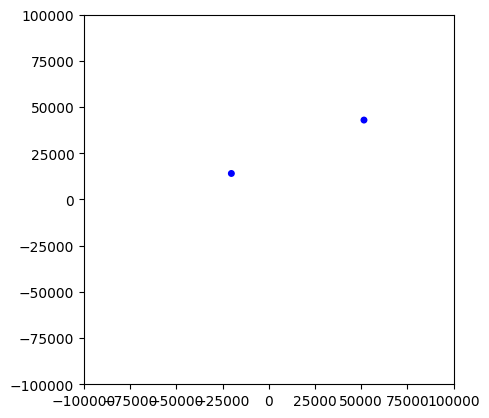

In [143]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()

ax.set_xlim(-10**5, 10**5)
ax.set_ylim(-10**5, 10**5)
ax.set_aspect('equal')

circles = [ax.add_patch(plt.Circle((0,0), radius=b.mass/200000, color='b')) for b in bodies]

def update(frame):
    for i, body in enumerate(bodies):
        circles[i].center = body.history_pos[frame][0:2]
    if frame%20==0:
        print(frame)
    return circles

ani = FuncAnimation(fig, update, frames=len(bodies[0].history_pos), blit=True)

ani.save('simulation.gif', writer='pillow', fps=30)

print("GIF saved successfully as simulation.gif")

In [144]:
# #lets draw a visualization!!!

# fig, axies = plt.subplots()

# body_1 = axies.add_patch(plt.Circle(bodies[0].history_pos[0][0:2], radius = bodies[0].mass/200000, color = 'b'))
# body_2 = axies.add_patch(plt.Circle(bodies[1].history_pos[0][0:2], radius = bodies[1].mass/200000, color = 'b'))
# body_3 = axies.add_patch(plt.Circle(bodies[2].history_pos[0][0:2], radius = bodies[2].mass/200000, color = 'b'))
# axies.add_patch(body_1)
# axies.add_patch(body_2)
# axies.add_patch(body_3)

    
# def update(frame):
#     body_1.center = bodies[0].history_pos[frame][0:2]
#     body_2.center = bodies[1].history_pos[frame][0:2]
#     body_3.center = [frame*1000, frame*1000]
#     return (body_1, body_2, body_3)


# axies.set_xlim(-10**5, 10**5)
# axies.set_ylim(-10**5, 10**5)
# axies.set_aspect('equal', adjustable='box')

# animate = animation.FuncAnimation(fig=fig, func=update, frames=1000, interval=20, blit=True, repeat=True)

# plt.show()